# Compton scattering & bremsstrahlung -- the photon as a particle
### one shows the photon has MOMENTUM, the other shows it has an ENERGY quantum

Two experiments that forced light to be a particle:

- **Compton scattering:** a photon bouncing off a free electron comes back with a
  longer wavelength, shifted by $\Delta\lambda=\lambda_C(1-\cos\theta)$ -- pure
  relativistic energy-momentum conservation, proof that the photon carries momentum
  $p=h/\lambda$.
- **Bremsstrahlung:** an electron braking in matter (an X-ray tube) emits a continuous
  spectrum with a sharp short-wavelength cutoff $\lambda_{\min}=hc/(eV)$ -- the whole
  kinetic energy $eV$ becoming one photon. You cannot make a photon more energetic
  than the electron that made it.

Both are computed in `griffiths/modern.py`. Civilian education.

In [1]:
import numpy as np, matplotlib.pyplot as plt
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from griffiths import modern as mp
eV = 1.602176634e-19
print(f"Compton wavelength lambda_C = {mp.compton_wavelength()*1e12:.4f} pm; "
      f"electron rest energy = {mp.electron_rest_energy()/eV/1e3:.1f} keV")

Compton wavelength lambda_C = 2.4263 pm; electron rest energy = 511.0 keV


## 1. The Compton wavelength shift

The shift depends only on the scattering angle (not the incident wavelength): zero
straight through, one $\lambda_C$ at 90 degrees, and a maximum of $2\lambda_C$ on
backscatter. The scattered photon's energy falls correspondingly.

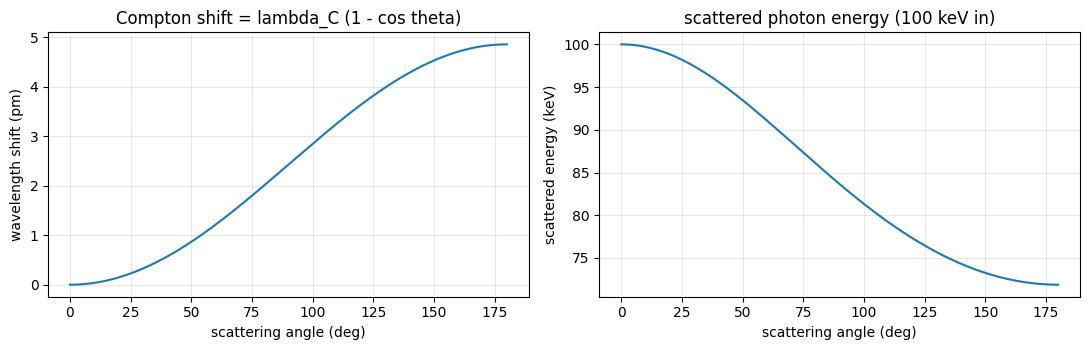

backscatter: shift = 4.853 pm = 2 lambda_C; E' = 71.9 keV (the Compton edge)


In [2]:
theta = np.linspace(0, np.pi, 300)
E_in = 100e3 * eV                                 # a 100 keV photon
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(np.degrees(theta), mp.compton_shift(theta)*1e12)
ax[0].set(xlabel="scattering angle (deg)", ylabel="wavelength shift (pm)",
          title="Compton shift = lambda_C (1 - cos theta)")
ax[1].plot(np.degrees(theta), mp.compton_scattered_energy(E_in, theta)/eV/1e3)
ax[1].set(xlabel="scattering angle (deg)", ylabel="scattered energy (keV)",
          title="scattered photon energy (100 keV in)")
for a in ax: a.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"backscatter: shift = {mp.compton_shift(np.pi)*1e12:.3f} pm = 2 lambda_C; "
      f"E' = {mp.compton_scattered_energy(E_in, np.pi)/eV/1e3:.1f} keV (the Compton edge)")

## 2. It is just energy-momentum conservation (verify it)

The scattered-energy formula is the solution of relativistic conservation: the
electron carries off the missing energy and momentum, with
$E_e^2=(p_e c)^2+(m_e c^2)^2$. Check the residual is zero at every angle -- the
formula is *derived*, not fitted.

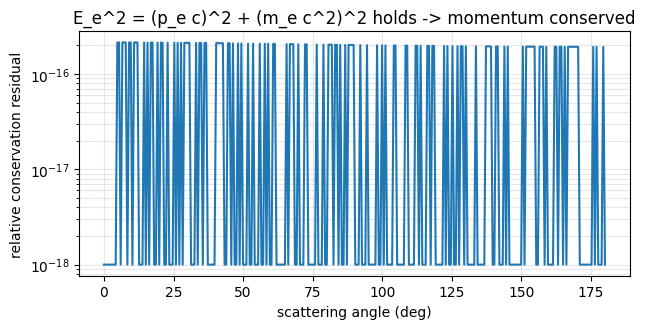

max relative residual: 2.14019056967242e-16 (~machine zero -> conservation satisfied)


In [3]:
c = 299792458.0; mec2 = mp.electron_rest_energy()
res = []
for th in theta:
    Ep = mp.compton_scattered_energy(E_in, th)
    Ee = E_in + mec2 - Ep
    pc2 = (E_in - Ep*np.cos(th))**2 + (Ep*np.sin(th))**2
    res.append(abs(Ee**2 - (pc2 + mec2**2)) / Ee**2)
plt.figure(figsize=(6.5,3.4))
plt.semilogy(np.degrees(theta), np.array(res)+1e-18)
plt.xlabel("scattering angle (deg)"); plt.ylabel("relative conservation residual")
plt.title("E_e^2 = (p_e c)^2 + (m_e c^2)^2 holds -> momentum conserved"); plt.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()
print("max relative residual:", max(res), "(~machine zero -> conservation satisfied)")

## 3. The Compton edge -- a spectrum of scattered energies

A detector collecting photons at all angles sees scattered energies spread from the
full incident energy (forward) down to the **Compton edge** (backscatter). Higher
incident energy means a deeper edge -- the relativistic $E/m_ec^2$ factor biting harder.

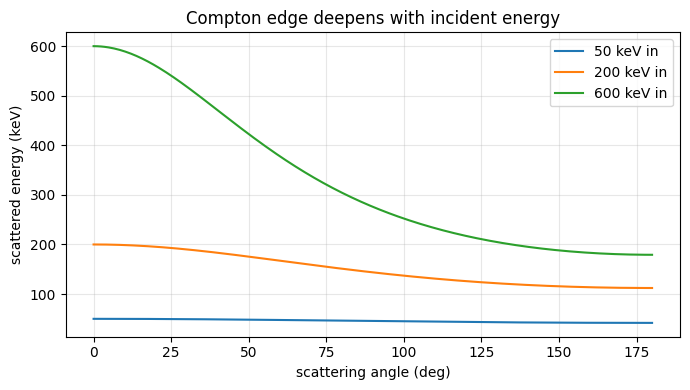

In [4]:
plt.figure(figsize=(7,4))
for keV in (50, 200, 600):
    E0 = keV*1e3*eV
    plt.plot(np.degrees(theta), mp.compton_scattered_energy(E0, theta)/eV/1e3, label=f"{keV} keV in")
plt.xlabel("scattering angle (deg)"); plt.ylabel("scattered energy (keV)")
plt.title("Compton edge deepens with incident energy"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4. Bremsstrahlung -- the X-ray continuum and its cutoff

A braking electron radiates a broad spectrum (Kramers' law), but **never below**
$\lambda_{\min}=hc/(eV)$: the hardest photon takes the electron's entire kinetic
energy. Raise the tube voltage and the cutoff slides to shorter wavelengths (harder
X-rays) -- the Duane-Hunt law, a direct readout of Planck's constant.

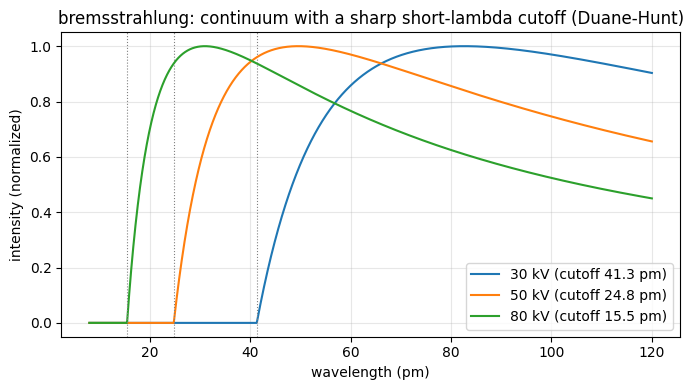

cutoff lambda_min = hc/(eV): doubling V halves it -> 24.80 pm at 50 kV, 12.40 pm at 100 kV


In [5]:
lam = np.linspace(8e-12, 120e-12, 3000)
plt.figure(figsize=(7,4))
for kV in (30, 50, 80):
    I = mp.bremsstrahlung_spectrum(lam, kV*1e3)
    lmin = mp.bremsstrahlung_cutoff_wavelength(kV*1e3)
    plt.plot(lam*1e12, I/I.max(), label=f"{kV} kV (cutoff {lmin*1e12:.1f} pm)")
    plt.axvline(lmin*1e12, color="gray", ls=":", lw=0.8)
plt.xlabel("wavelength (pm)"); plt.ylabel("intensity (normalized)")
plt.title("bremsstrahlung: continuum with a sharp short-lambda cutoff (Duane-Hunt)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print("cutoff lambda_min = hc/(eV): doubling V halves it ->",
      f"{mp.bremsstrahlung_cutoff_wavelength(50e3)*1e12:.2f} pm at 50 kV, "
      f"{mp.bremsstrahlung_cutoff_wavelength(100e3)*1e12:.2f} pm at 100 kV")

## What these two showed

1. **Compton:** the wavelength shift $\lambda_C(1-\cos\theta)$ is energy-momentum
   conservation for a photon of momentum $p=h/\lambda$ -- light is a particle, and we
   verified the conservation residual is machine-zero.
2. **Bremsstrahlung:** the continuum stops dead at $\lambda_{\min}=hc/(eV)$ -- the
   photon's energy is quantized by the electron that made it (Duane-Hunt = a way to
   measure $h$).

Together they pin down the photon: it has **momentum** (Compton) and a definite
**energy** $E=hc/\lambda$ (bremsstrahlung). The same quantization underlies every
detector and light source in this repo. Civilian education / modern physics.